In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
os.environ["LANGSMITH_PROJECT"]="AgenticLangGraphProject"

In [5]:
import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"

In [6]:
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000014D08404E90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000014D0861E750>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [9]:
## Graph With tool Call
from langchain_core.tools import tool

@tool
def add(a:float,b:float):
    """Add two number"""
    return a+b
tools=[add]
tool_node=ToolNode([add])

llm_with_tool=llm.bind_tools([add])

def llm_calling_tool(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}

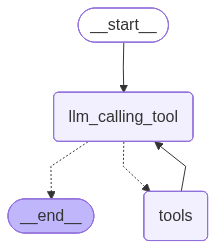

In [10]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
## Grpah
builder=StateGraph(State)
builder.add_node("llm_calling_tool",llm_calling_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "llm_calling_tool")
builder.add_conditional_edges(
    "llm_calling_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","llm_calling_tool")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
response=graph.invoke({"messages":"What is Machine Learning? Also add 2 and 3 and tell me the answer."})
response

{'messages': [HumanMessage(content='What is Langsmith?', additional_kwargs={}, response_metadata={}, id='15038a28-8ce2-4bf0-a291-9fdeff7d74bf'),
  AIMessage(content='brave_search{"query": "Langsmith"}', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 217, 'total_tokens': 228, 'completion_time': 0.031346305, 'completion_tokens_details': None, 'prompt_time': 0.024659223, 'prompt_tokens_details': None, 'queue_time': 0.14293509, 'total_time': 0.056005528}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d81de-61a4-71b1-9eb7-a5dc0ef1a25e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 217, 'output_tokens': 11, 'total_tokens': 228})]}